# 01 — Recomputation: Mukiibi & Mikelson (2026)

This notebook recomputes the analysis published in:

> Mukiibi, R. & Mikelson, J. (2026). *A Machine Learning Approach for GHI
> Bias Correction: Validation of Random Forest Performance Across
> Sub-Saharan Africa.* IEEE [conference forthcoming].

Headline numbers from the paper:

| | RMSE | MAE | R² | IOA |
|---|---|---|---|---|
| **RF (this paper)** | **0.57** | **0.43** | 0.39 | **0.60** |
| CAMS | 1.29 | 1.19 | 0.52 | 0.47 |
| NASA CERES | 1.24 | 1.13 | 0.46 | 0.46 |

(The paper's Table III reports daily-scale RF metrics on a 2-station
held-out fold — RMSE 0.41, MAE 0.32, R² 0.86. We deviate here: the
deployment bundle trains on all 28 stations and validates only on the
Katongole 54-station network, so we don't reproduce Table III. See §9.)

The notebook reproduces the full pipeline on the refactored SuSSE
infrastructure: warehouse-backed `FeatureService` for data assembly,
`FeatureSpec` with paper-faithful cleaners + derived features (including
the `LongitudeFeature` escape hatch), `Trainer` for fit + scoring,
`TrainedBundle` for the deliverable, and `wandb` for run/artifact tracing
shared with the co-author.

**Deliverable:** the trained bundle is the model that
[`Irradiation_Portal`](../../../) loads at startup. After this notebook
runs successfully with W&B enabled, point the portal's bundle path at
the saved directory.

### Inputs, outputs, prerequisites

| | |
|---|---|
| **Inputs** | `ground_measurements` (28 stations) + `nasa_daily_vars_long` + `cams_daily_vars_long` + `irradiance_daily` from the warehouse; the local Katongole CSV at `reference_data/katongole_2023_monthly.csv`. |
| **Outputs** | A `TrainedBundle` saved to `data/bundles/mukiibi_mikelson_2026/` and (optionally) a versioned W&B artifact under `WANDB_PROJECT` / `WANDB_ENTITY`. |
| **Prerequisites** | Application Default Credentials for BigQuery (`gcloud auth application-default login`); for `LOG_TO_WANDB=True`, a `wandb` login configured for the team entity. |
| **Wall time** | ~5 min (warehouse fetch + RF train) on a workstation. The 54-station Katongole inference pulls one BQ row per (station, date) — keep that loop scoped to one year. |

The notebook **does not** depend on the standalone MERRA-2 OPeNDAP
ingest (`b9`) — the paper sources its "MERRA-2" variables via NASA
POWER, which our `nasa_daily_vars_long` already carries. b9's
incremental MERRA-2 AOD decomposition is reserved for the next-iteration
model beyond this paper.

## 0 — Setup

In [20]:
%load_ext autoreload
%autoreload 2

import sys
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pygeohash

# Resolve the project root from the notebook's location, so imports work
# regardless of where Jupyter was launched.
_NB_DIR = Path.cwd().resolve()
_PROJECT_ROOT = _NB_DIR
while _PROJECT_ROOT != _PROJECT_ROOT.parent and not (_PROJECT_ROOT / "src" / "susse").exists():
    _PROJECT_ROOT = _PROJECT_ROOT.parent
sys.path.insert(0, str(_PROJECT_ROOT / "src"))

print(f"project root: {_PROJECT_ROOT}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
project root: /home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation


In [21]:
# ----- Top-level configuration -----
# Paper-recomputation parameters. Override these to deviate from the
# paper's setup; document any deviation in section 9.

# W&B project for the recomputation. Public-visibility personal-entity
# project: Jan owns it, the student reads via URL after the first run
# lands and the project's privacy is flipped to "Public" in the W&B UI.
# A free Team plan would be cleaner but requires a paid tier for shared
# write access, which isn't worth it for an academic recomputation.
# Set LOG_TO_WANDB=True when actually running for record. Keep False for
# dev iterations to avoid creating throwaway runs.
WANDB_PROJECT = "susse-mukiibi-mikelson-2026"
WANDB_ENTITY = None        # None → your wandb-login default user entity
LOG_TO_WANDB = False
WANDB_TAGS = ("paper-recomputation", "random-forest")

# Paper-faithful Random Forest hyperparameters (paper §III).
RF_N_ESTIMATORS = 200
RF_MIN_SAMPLES_LEAF = 5
RF_RANDOM_STATE = 42

# Train-time random holdout fraction. We deviate from the paper here:
# the paper held out 2 of 24 stations spatially to produce daily-scale
# Table III metrics. With only 28 ground stations and a deployment
# bundle going to Irradiation_Portal, every station matters — the cost
# of a 2-station spatial holdout (~7% of training data, paper-internal
# methodology not a publishable claim) outweighs the granularity gain.
# We train on all stations and validate on Katongole only (paper Table
# IV). The Trainer still requires a non-empty val split to populate
# val_metrics; a small random row-level holdout serves as an
# in-distribution sanity check, not the validation.
RANDOM_VAL_FRACTION = 0.1
RANDOM_VAL_SEED = 42

# Validation year. Paper used 2021; we use 2024 because that's the year
# our Uganda grid covers for every Katongole station. Both years sit
# inside the Katongole 7-year (2017-2022) climatology window, so the
# year-mismatch is symmetric and the *relative* improvement over raw
# satellites is the comparable metric across both runs.
VALIDATION_YEAR = 2024

# Where to drop the trained-bundle directory. The Irradiation_Portal
# loads a bundle from a configurable path; keep this stable.
BUNDLES_ROOT = (_PROJECT_ROOT / "data" / "bundles").resolve()
BUNDLE_DEST = BUNDLES_ROOT / "mukiibi_mikelson_2026"

# Reference data co-located with this notebook.
KATONGOLE_CSV = _NB_DIR / "reference_data" / "katongole_2023_monthly.csv"
assert KATONGOLE_CSV.exists(), f"Missing reference data at {KATONGOLE_CSV}"
print(f"Random val fraction: {RANDOM_VAL_FRACTION}")
print(f"Validation year:     {VALIDATION_YEAR}")
print(f"Bundle dest:         {BUNDLE_DEST}")

Random val fraction: 0.1
Validation year:     2024
Bundle dest:         /home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/data/bundles/mukiibi_mikelson_2026


## 1 — Paper-faithful feature selection

Paper Table II lists 39 predictors. They map to our warehouse catalog as
follows (CERES SYN1deg + GMAO MERRA-2 fields are both served via NASA
POWER, which keeps the recomputation single-source for satellite data):

* **CERES SYN1deg radiation/cloud/aerosol** → 10 columns from `nasa_daily_vars_long`
* **GMAO MERRA-2 meteorology** (via NASA POWER) → 14 columns from `nasa_daily_vars_long`
* **CAMS irradiance** → 5 aux columns + the `sat_ghi_cams_kwh_m2_day` series via `irradiance_daily`
* **NASA CERES GHI** → `sat_ghi_nasa_kwh_m2_day` via `irradiance_daily`
* **Derived** → `kt_cams`, `doy_sin`/`doy_cos`, `altitude`, `longitude` (paper-faithful — see `LongitudeFeature` docstring)

In [22]:
from susse.datasets import FeatureSelection
from susse.warehouse_ops.population.types import Source

# CERES SYN1deg + GMAO MERRA-2, all served via NASA POWER.
#
# Two of the paper's 39 predictors — NASA DHI (ALLSKY_SFC_SW_DIFF) and
# NASA DNI (ALLSKY_SFC_SW_DNI) — exist in our dim_variable catalog but
# were never ingested into nasa_daily_vars_long. They live only in the
# wide irradiance_daily table, and FeatureService doesn't currently
# emit DHI/DNI columns from that table (only GHI as
# sat_ghi_<source>_kwh_m2_day). We drop them from this recomputation
# rather than NaN-ing every row; paper Fig. 3 shows DHI/DNI sit far
# below the top-9 features by importance (>50% is ghi_cams alone), so
# the impact on RMSE should be small. Documented as a deviation in §9.
NASA_AUX_VARIABLE_IDS: tuple[str, ...] = (
    # --- CERES SYN1deg radiation/aerosol/cloud ---
    "longwave_downward_irr",         # CLRSKY_SFC_LW_DWN
    "aod_550_adj",                   # AOD_55_ADJ
    "cloud_amount",                  # CLOUD_AMT
    "precipitable_water",            # PW
    "airmass",                       # AIRMASS
    "zero_plane_displacement",       # DISPH
    "surface_albedo",                # SRF_ALB_ADJ
    "clearness_index",               # ALLSKY_KT
    # --- GMAO MERRA-2 (via NASA POWER) ---
    "temperature",                   # T2M
    "relative_humidity",             # RH2M
    "surface_pressure",              # PS
    "wind_speed",                    # WS2M
    "temperature_range",             # T2M_RANGE
    "precipitation_corrected",       # PRECTOTCORR
    "surface_roughness",             # Z0M
    "northern_wind",                 # V2M
    "evapotranspiration_energy",     # EVPTRNS
    "planetary_boundary",            # PBLTOP
    "total_column_ozone",            # TO3
    "surface_air_density",           # RHOA
    "evaporation_land",              # EVLAND
    "surface_soil_wetness",          # GWETTOP
)

# CAMS aux variables (the GHI series itself is pulled via include_satellite_irradiance).
# Same DHI/DNI infrastructure gap as NASA — CAMS dhi/dni live in
# irradiance_daily, not in cams_daily_vars_long, and FeatureService
# doesn't expose them today. Dropped from the recomputation.
CAMS_VARIABLE_IDS: tuple[str, ...] = (
    "ghi_clear",   # ghi_clear_cams
    "dhi_clear",   # dhi_clear_cams
    "dni_clear",   # dni_clear_cams
)

selection = FeatureSelection(
    nasa_variable_ids=NASA_AUX_VARIABLE_IDS,
    cams_variable_ids=CAMS_VARIABLE_IDS,
    include_satellite_irradiance=(Source.NASA_POWER, Source.CAMS),
    qc_levels=("pass",),
)
print(f"Selection: {len(NASA_AUX_VARIABLE_IDS)} NASA aux + {len(CAMS_VARIABLE_IDS)} CAMS aux + 2 satellite GHI series")

Selection: 22 NASA aux + 3 CAMS aux + 2 satellite GHI series


## 2 — Build the training dataset from the warehouse

`FeatureService` joins ground GHI to the satellite + aux columns. The
paper trained on 24 sites; our `ground_measurements` table has 28 — the
extra ones are stations the paper didn't have access to at submission
time. We use **all 28 stations** for training (see §4 for why we drop
the paper's 2-station spatial holdout) and validate exclusively on the
Katongole network in §6.

In [23]:
from susse.warehouse_ops.io import BigQueryClient, WarehouseConfig
from susse.warehouse_ops.io.config import TableRefs
from susse.datasets import FeatureService, DatasetManifest, TrainingDataset
from susse.provenance import git_sha, susse_version

bq = BigQueryClient(config=WarehouseConfig())
tables = TableRefs(config=bq.config)
service = FeatureService(bq=bq, tables=tables)

# All available ground stations.
station_meta = bq.query(
    f"SELECT location, MIN(date) AS min_date, MAX(date) AS max_date, COUNT(*) AS n_rows "
    f"FROM `{tables.ground_measurements}` GROUP BY location ORDER BY location"
)
print(f"{len(station_meta)} stations in ground_measurements:")
print(station_meta.to_string(index=False))

28 stations in ground_measurements:
            location   min_date   max_date  n_rows
     egypt_location1 2023-09-01 2024-11-25     452
     ghana_location1 2019-09-24 2024-11-25    1774
     ghana_location2 2020-01-31 2024-05-02    1105
     ghana_location3 2021-02-25 2024-11-25    1320
             kampala 2011-04-06 2023-01-22    1798
    kenya_location10 2023-10-26 2024-11-25     671
    kenya_location11 2024-03-02 2024-11-25     519
    kenya_location12 2024-02-09 2024-11-25     287
    kenya_location13 2023-10-25 2024-11-25     693
    kenya_location14 2023-10-25 2024-11-25     371
     kenya_location2 2019-10-08 2024-02-23    1016
     kenya_location3 2019-05-28 2024-11-25    1976
     kenya_location4 2019-07-24 2022-01-28     876
     kenya_location5 2020-12-22 2024-11-25    1382
     kenya_location6 2021-01-13 2024-11-25     988
     kenya_location7 2021-01-12 2022-11-29     554
     kenya_location8 2023-01-21 2024-11-25     673
     kenya_location9 2024-02-29 2024-11-25    

/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [24]:
# Pull all ground measurements + satellite features for the entire
# date span. The Preprocessor's cleaners will then filter rows.
DATE_START = station_meta["min_date"].min()
DATE_END = station_meta["max_date"].max()

raw_df = service.build_training_pairs(
    selection=selection,
    date_start=DATE_START,
    date_end=DATE_END,
)
print(f"Raw training pairs: {len(raw_df):,} rows × {len(raw_df.columns)} columns")
print(f"Date span: {DATE_START} .. {DATE_END}")
print(f"Stations: {raw_df['location'].nunique()}")
raw_df.head(3)

/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Raw training pairs: 25,043 rows × 34 columns
Date span: 2011-03-08 .. 2024-11-25
Stations: 28


,date,location,lat,lon,geohash5,y_ghi_kwh_m2_day,qc_level,sat_ghi_nasa_kwh_m2_day,sat_ghi_cams_kwh_m2_day,nasa_longwave_downward_irr,...,nasa_northern_wind,nasa_evapotranspiration_energy,nasa_planetary_boundary,nasa_total_column_ozone,nasa_surface_air_density,nasa_evaporation_land,nasa_surface_soil_wetness,cams_ghi_clear,cams_dhi_clear,cams_dni_clear
0,2011-03-08,tororo,0.6978,34.17151,sb07c,7.092422,pass,7.8041,7.986973,7.8365,...,0.12,1.6164,73.24,265.86,1.01,4.51,0.45,8.054816,0.997226,9.881710
1,2011-03-09,tororo,0.6978,34.17151,sb07c,7.063011,pass,7.4856,7.748071,7.9466,...,-0.96,1.4921,72.04,265.87,1.01,4.38,0.43,8.077322,1.173907,9.586037
2,2011-03-10,tororo,0.6978,34.17151,sb07c,6.502057,pass,7.2958,7.512890,7.8919,...,-0.50,1.1918,72.12,267.10,1.01,3.79,0.41,8.175606,1.042803,9.964738


In [25]:
# Wrap the DataFrame in the typed TrainingDataset shape that the
# Preprocessor expects. We're not snapshotting it to disk — for the
# paper recomputation, the assembly is fast enough to redo on demand.
manifest = DatasetManifest(
    name="mukiibi_mikelson_2026_train",
    version="recomputation_v1",
    created_at_utc=pd.Timestamp.now(tz="UTC").isoformat(),
    susse_version=susse_version(),
    git_sha=git_sha(),
    feature_selection=selection,
    date_start=DATE_START,
    date_end=DATE_END,
    location_filter=None,
    warehouse_project=bq.config.project_id,
    warehouse_dataset=bq.config.dataset,
    warehouse_table_mods=service.warehouse_table_mods(selection),
    n_rows=len(raw_df),
    n_cols=len(raw_df.columns),
    column_names=tuple(raw_df.columns),
    content_hash="recomputation",  # not snapshotted to disk → no content hash
)
dataset = TrainingDataset(df=raw_df, manifest=manifest)
print(f"Dataset: {dataset.manifest.name} {dataset.manifest.version}")

Dataset: mukiibi_mikelson_2026_train recomputation_v1


/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


## 3 — Configure preprocessing

Paper-faithful `FeatureSpec`:

* **Cleaners** (paper §II.A "Target variable" curation rules):
  `GhiUpperBoundCleaner(threshold=12.0)` → drop physically-impossible
  values; `IqrLowerBoundCleaner(multiplier=1.5)` → Tukey lower fence;
  `HighMissingYearExcluder(missing_fraction_threshold=0.05)` → drop
  sparse (station, year) groups; `KnnYearGapImputer(k=5)` → fill
  remaining smaller gaps via temporal kNN.
* **Pass-through features**: every aux column requested in the
  `FeatureSelection`, plus the two satellite GHI series.
* **Derived features**: `kt_cams` (CAMS clear-sky index),
  `doy_sin`/`doy_cos` (cyclical day-of-year), `altitude` (pvlib
  Open-Elevation lookup), and `longitude` (the paper's coordinate-as-
  feature choice — see `LongitudeFeature` docstring for the anti-pattern
  caveat).

In [26]:
from susse.preprocessing import (
    AltitudeFeature,
    ClearSkyIndexFeature,
    CyclicalDayOfYearFeature,
    FeatureSpec,
    GhiUpperBoundCleaner,
    HighMissingYearExcluder,
    IqrLowerBoundCleaner,
    KnnYearGapImputer,
    LongitudeFeature,
    Preprocessor,
    PvlibElevationProvider,
)

# Pass-through feature columns: every requested aux variable + the two
# satellite GHI series. These names are produced by the FeatureService.
feature_columns = (
    *(f"nasa_{v}" for v in NASA_AUX_VARIABLE_IDS),
    *(f"cams_{v}" for v in CAMS_VARIABLE_IDS),
    "sat_ghi_nasa_kwh_m2_day",
    "sat_ghi_cams_kwh_m2_day",
)

spec = FeatureSpec(
    target_column="y_ghi_kwh_m2_day",
    feature_columns=feature_columns,
    cleaners=(
        # FeatureService.build_training_pairs renames the ground-truth
        # column from `ghi_kwh_m2_day` (warehouse) to `y_ghi_kwh_m2_day`
        # (assembled frame). Every target-column-aware cleaner needs the
        # renamed column name explicitly — the cleaners' defaults match
        # the warehouse convention, not the FeatureService convention.
        GhiUpperBoundCleaner(column="y_ghi_kwh_m2_day", threshold=12.0),
        IqrLowerBoundCleaner(column="y_ghi_kwh_m2_day", multiplier=1.5),
        HighMissingYearExcluder(missing_fraction_threshold=0.05),
        KnnYearGapImputer(target_column="y_ghi_kwh_m2_day", k=5),
    ),
    derived_features=(
        ClearSkyIndexFeature(
            ghi_column="sat_ghi_cams_kwh_m2_day",
            ghi_clear_column="cams_ghi_clear",
            output_column="kt_cams",
        ),
        CyclicalDayOfYearFeature(),
        AltitudeFeature(provider=PvlibElevationProvider()),
        LongitudeFeature(),  # paper-faithful — see docstring re: ~28-station memorisation
    ),
    id_columns=("date", "location", "geohash5", "lat", "lon"),
)

print(f"FeatureSpec: {len(spec.cleaners)} cleaners, "
      f"{len(spec.derived_features)} derived features, "
      f"{len(spec.feature_columns)} pass-through columns")
print(f"Total model features: {len(spec.output_feature_names)}")

FeatureSpec: 4 cleaners, 4 derived features, 27 pass-through columns
Total model features: 32


In [27]:
# Apply the preprocessor. The cleaners run first (target outlier
# rejection + missing-year handling + kNN imputation), then derived
# features compute on the cleaned frame.
processed = Preprocessor(spec).apply(dataset)
print(f"Processed: {processed.n_rows:,} rows × {processed.n_features} features")
print(f"Stations after cleaning: {processed.df['location'].nunique()}")
processed.df[list(processed.feature_columns) + [spec.target_column]].head(3)

Processed: 16,326 rows × 32 features
Stations after cleaning: 25


,nasa_longwave_downward_irr,nasa_aod_550_adj,nasa_cloud_amount,nasa_precipitable_water,nasa_airmass,nasa_zero_plane_displacement,nasa_surface_albedo,nasa_clearness_index,nasa_temperature,nasa_relative_humidity,...,cams_dhi_clear,cams_dni_clear,sat_ghi_nasa_kwh_m2_day,sat_ghi_cams_kwh_m2_day,kt_cams,doy_sin,doy_cos,altitude_m,longitude,y_ghi_kwh_m2_day
0,9.3283,0.28,5.97,2.63,3.61,0.05,0.35,0.71,29.35,59.34,...,2.000355,7.190065,7.0534,7.064093,1.0,-0.857315,-0.514793,110.0,32.460447,6.428052
1,9.1291,0.3,6.23,2.41,3.65,0.05,0.35,0.71,28.94,54.39,...,1.311028,8.844054,7.026,7.397833,1.0,-0.866025,-0.500000,110.0,32.460447,6.601826
2,9.0026,0.3,5.34,2.21,3.69,0.05,0.36,0.7,28.55,54.41,...,1.420032,8.687866,6.9497,7.129047,0.966686,-0.874481,-0.485060,110.0,32.460447,6.600638


## 3.5 — Training data exploration

Before fitting, take a look at what the model is being asked to learn:

* **Target distribution per station** — are some stations consistently
  brighter / dimmer? Which ones have wide variance, which are
  near-constant?
* **Satellite-vs-ground scatter** — the bias the model is asked to
  correct. The diagonal is perfect agreement; off-diagonal spread is
  the signal RF will try to compress.
* **Correlation heatmap** — which features carry signal about the
  target, and which features are redundant with each other.
* **PCA scatter coloured by station** — do stations cluster in feature
  space? Outliers are out-of-distribution candidates that the RF won't
  generalise to.

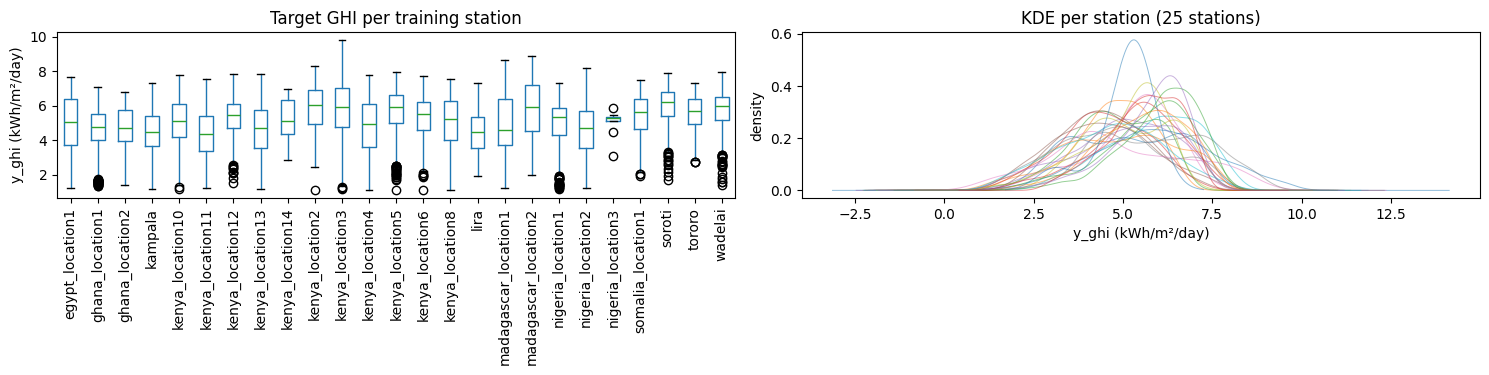

In [28]:
# Target distribution per station — boxplot + per-station KDE.
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
processed.df.boxplot(
    column=spec.target_column, by="location", rot=90, ax=axes[0],
    grid=False,
)
axes[0].set_title("Target GHI per training station")
axes[0].set_ylabel("y_ghi (kWh/m²/day)")
axes[0].set_xlabel("")
plt.suptitle("")  # drop pandas' auto-title

ax = axes[1]
locs = sorted(processed.df["location"].unique())
for loc in locs:
    sub = processed.df[processed.df["location"] == loc][spec.target_column]
    if len(sub) > 1:
        sub.plot.kde(ax=ax, alpha=0.5, lw=0.7)
ax.set_xlabel("y_ghi (kWh/m²/day)")
ax.set_ylabel("density")
ax.set_title(f"KDE per station ({len(locs)} stations)")
fig.tight_layout()
plt.show()

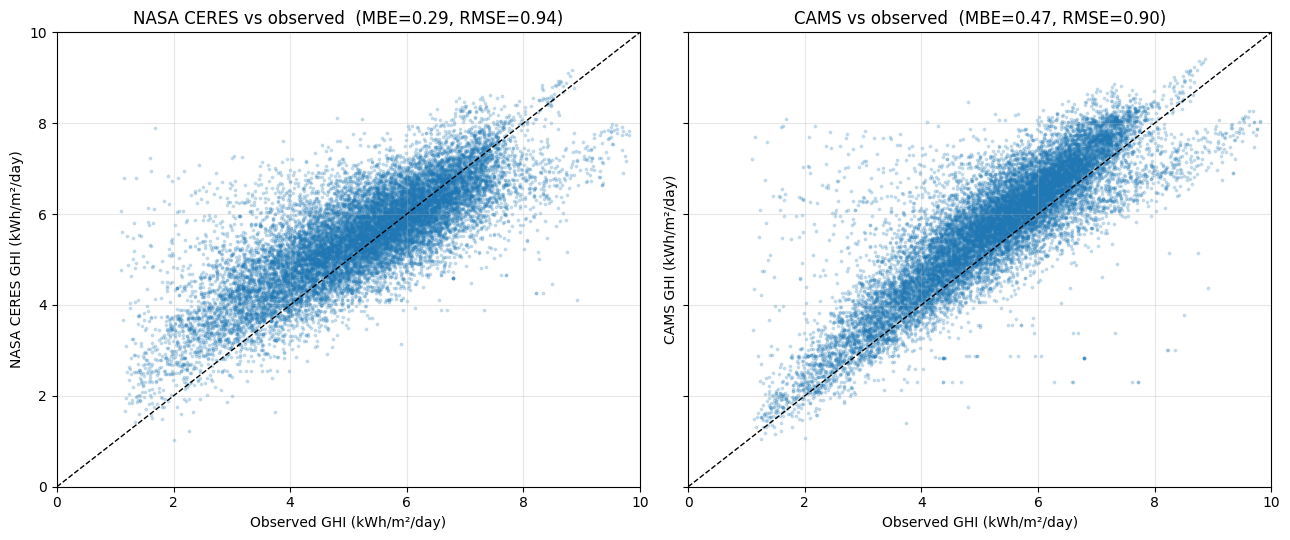

In [29]:
# The bias the model is asked to correct: raw satellite GHI vs
# ground truth, daily, every training row.
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for ax, sat_col, label in zip(
    axes,
    ("sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day"),
    ("NASA CERES", "CAMS"),
):
    ax.scatter(
        processed.df[spec.target_column], processed.df[sat_col],
        s=3, alpha=0.2, color="C0",
    )
    lim = (0, 10)
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Observed GHI (kWh/m²/day)")
    ax.set_ylabel(f"{label} GHI (kWh/m²/day)")
    err = processed.df[sat_col] - processed.df[spec.target_column]
    ax.set_title(f"{label} vs observed  (MBE={err.mean():.2f}, RMSE={np.sqrt((err**2).mean()):.2f})")
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

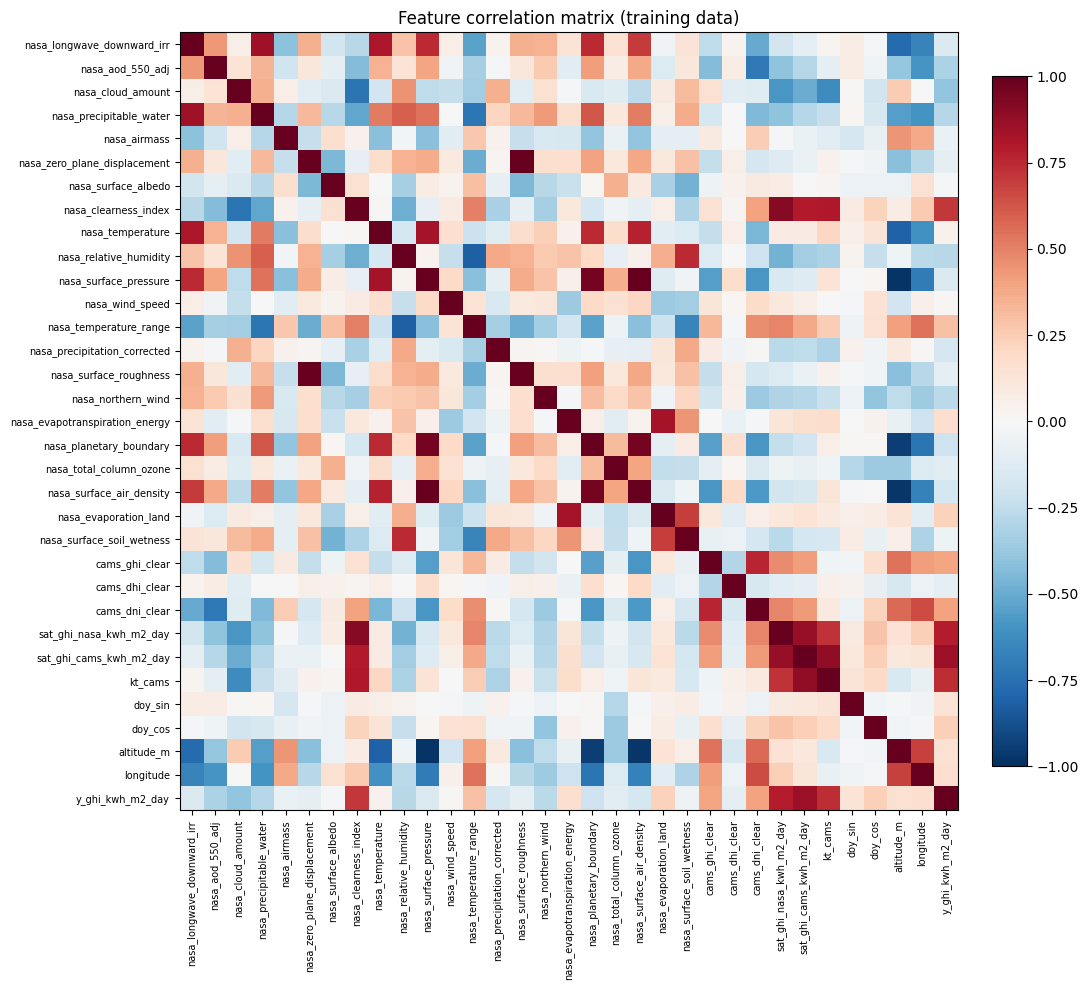

Top 10 features by |correlation| with y_ghi_kwh_m2_day:
sat_ghi_cams_kwh_m2_day    0.854
sat_ghi_nasa_kwh_m2_day    0.784
kt_cams                    0.739
nasa_clearness_index       0.705
cams_dni_clear             0.404
nasa_cloud_amount          0.398
cams_ghi_clear             0.393
nasa_aod_550_adj           0.313
nasa_temperature_range     0.296
nasa_precipitable_water    0.287


In [30]:
# Pairwise correlations: which features carry signal about the
# target? Top-N report below the heatmap.
corr_cols = list(processed.feature_columns) + [spec.target_column]
corr = processed.df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns, fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
ax.set_title("Feature correlation matrix (training data)")
fig.tight_layout()
plt.show()

target_corr = (
    corr[spec.target_column].drop(spec.target_column).abs().sort_values(ascending=False)
)
print(f"Top 10 features by |correlation| with {spec.target_column}:")
print(target_corr.head(10).round(3).to_string())

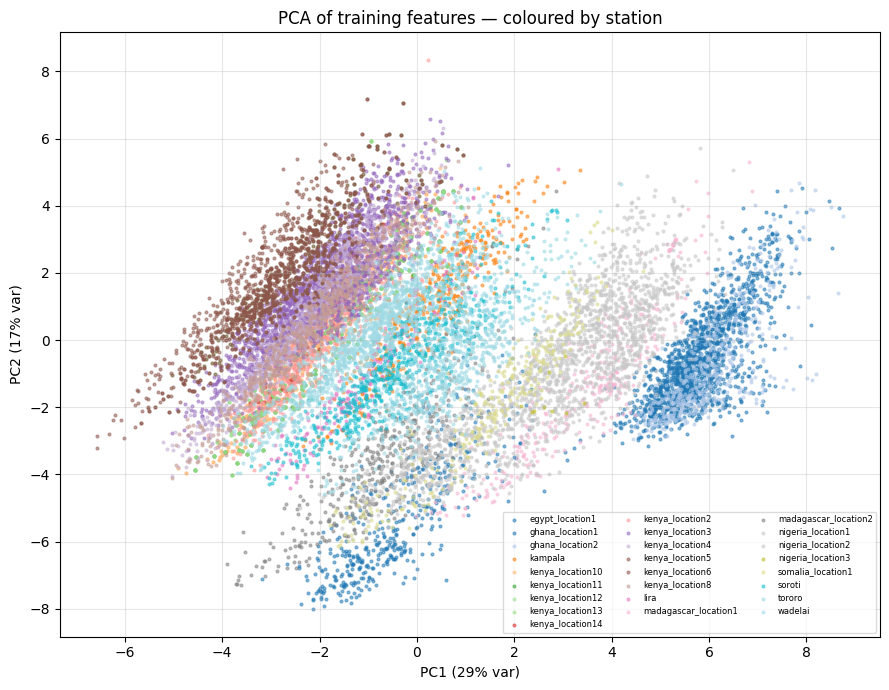

In [31]:
# PCA of the standardised feature matrix. A station that sits far
# from the rest in feature space is an OOD candidate the model won't
# generalise to.
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_train_arr = processed.X().to_numpy()
scaler = StandardScaler()
Xs = scaler.fit_transform(X_train_arr)
pca = PCA(n_components=2)
pcs = pca.fit_transform(Xs)
explained = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 7))
loc_arr = processed.df["location"].to_numpy()
unique_locs = sorted(set(loc_arr))
cmap = plt.get_cmap("tab20", max(20, len(unique_locs)))
for i, loc in enumerate(unique_locs):
    mask = loc_arr == loc
    ax.scatter(
        pcs[mask, 0], pcs[mask, 1], s=4, alpha=0.5,
        color=cmap(i % cmap.N), label=loc,
    )
ax.set_xlabel(f"PC1 ({explained[0]:.0%} var)")
ax.set_ylabel(f"PC2 ({explained[1]:.0%} var)")
ax.set_title("PCA of training features — coloured by station")
ax.legend(fontsize=6, ncol=3, loc="best", framealpha=0.7)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 4 — Train/val split

**Deviation from the paper.** The paper held out 2 of 24 stations
spatially to produce daily-scale Table III metrics. With only 28
ground stations and a deployment bundle going to the portal, we train
on all stations and treat the **Katongole 54-station network** (§6) as
the real validation — that's the publishable claim from paper Table IV.

The `Trainer` still requires a non-empty val split to populate
`val_metrics`. We use a small random row-level holdout (in-distribution
sanity check, not the validation). The random val rows still come from
training stations, so a high score there only tells us the model isn't
broken; it doesn't measure generalisation. Katongole does.

In [32]:
from susse.preprocessing import PreprocessedDataset


def make_random_holdout_splitter(
    val_fraction: float, *, seed: int,
):
    """Splitter: random row-level holdout for in-distribution val_metrics."""
    def splitter(processed: PreprocessedDataset) -> tuple[pd.Index, pd.Index]:
        rng = np.random.default_rng(seed)
        n = len(processed.df)
        n_val = max(1, int(round(val_fraction * n)))
        # Permute index and split, so the split is reproducible across runs
        # with the same seed.
        permuted = rng.permutation(processed.df.index.to_numpy())
        val = permuted[:n_val]
        train = permuted[n_val:]
        return pd.Index(train), pd.Index(val)

    splitter.__name__ = f"random_holdout[frac={val_fraction},seed={seed}]"
    return splitter


splitter = make_random_holdout_splitter(
    val_fraction=RANDOM_VAL_FRACTION, seed=RANDOM_VAL_SEED,
)
train_idx, val_idx = splitter(processed)
print(f"Train: {len(train_idx):,} rows from {processed.df.loc[train_idx, 'location'].nunique()} stations")
print(f"Val:   {len(val_idx):,} rows  (random in-distribution holdout — sanity check, not validation)")

Train: 14,693 rows from 25 stations
Val:   1,633 rows  (random in-distribution holdout — sanity check, not validation)


## 5 — Train the Random Forest

Paper hyperparameters: `n_estimators=200`, `min_samples_leaf=5`,
`random_state=42`. The `Trainer` also scores raw NASA / CAMS GHI as
baselines on the val fold (paper §IV.B Table IV) — those rows make the
"satellite vs bias-corrected" comparison legible inside the `JobResult`.

When `LOG_TO_WANDB=True`, the trainer creates a W&B run, logs the
metrics, and uploads the bundle directory as an artifact of type
`trained_model`. Sharing the run with the co-author is two clicks in
the W&B UI under the team-entity workspace once `WANDB_ENTITY` is set
correctly.

In [33]:
from susse.models import RandomForestParams
from susse.training import Trainer, TrainerConfig

trainer_config = TrainerConfig(
    wandb_project=WANDB_PROJECT if LOG_TO_WANDB else None,
    wandb_entity=WANDB_ENTITY,
    wandb_tags=WANDB_TAGS,
)
trainer = Trainer(trainer_config)

bundle = trainer.train(
    processed=processed,
    params=RandomForestParams(
        n_estimators=RF_N_ESTIMATORS,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF,
        random_state=RF_RANDOM_STATE,
    ),
    splitter=splitter,
    holdout_label=(
        f"random-holdout:frac={RANDOM_VAL_FRACTION},seed={RANDOM_VAL_SEED} "
        f"(in-distribution sanity; real validation is Katongole §6)"
    ),
    bundle_dest=BUNDLE_DEST,
)
print(f"Trained: {type(bundle.regressor).__name__}")
print(f"Bundle:  {BUNDLE_DEST}")

Trained: RandomForestRegressor
Bundle:  /home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/data/bundles/mukiibi_mikelson_2026


In [34]:
# In-distribution sanity check on the random val holdout. NOT the
# headline validation — Katongole is (§6 below). A high score here
# only tells us the model fits its own distribution.
val = bundle.metadata.val_metrics
print(f"=== In-distribution val sanity check ===")
print(f"n_rows  = {val.n_rows:,}")
print(f"RMSE    = {val.rmse:.3f}")
print(f"MAE     = {val.mae:.3f}")
print(f"R²      = {val.r2:.3f}")

print(f"\n=== Baseline comparisons on the val fold ===")
for label, scores in bundle.metadata.baseline_metrics.items():
    print(f"{label:30s} RMSE={scores.rmse:.3f}  MAE={scores.mae:.3f}  R²={scores.r2:.3f}")

=== In-distribution val sanity check ===
n_rows  = 1,633
RMSE    = 0.567
MAE     = 0.381
R²      = 0.847

=== Baseline comparisons on the val fold ===
sat_ghi_nasa_kwh_m2_day        RMSE=0.925  MAE=0.695  R²=0.592
sat_ghi_cams_kwh_m2_day        RMSE=0.894  MAE=0.663  R²=0.620


## 5.5 — Training-set fit diagnostics

Sanity checks on the trained model **before** running the Katongole
validation. The plots below are *in-sample* — the model has seen every
station here during training, so it should fit them well. If it
doesn't, something is broken upstream (preprocessing, feature spec,
data quality) before we get to comparing against Katongole.

* **Yearly time series for 6 training stations** — observed vs RF (in-sample)
  vs raw NASA / CAMS, weekly-resampled for readability. Look for: RF
  closely tracking observed (it should), NASA/CAMS systematically
  high (the bias the model corrects).
* **Predicted-vs-observed scatter** — single panel across all
  training rows. Tight diagonal = model fits training distribution.

Plotting yearly time series for: ['kenya_location3', 'ghana_location1', 'tororo', 'kenya_location5', 'nigeria_location1', 'kenya_location4']


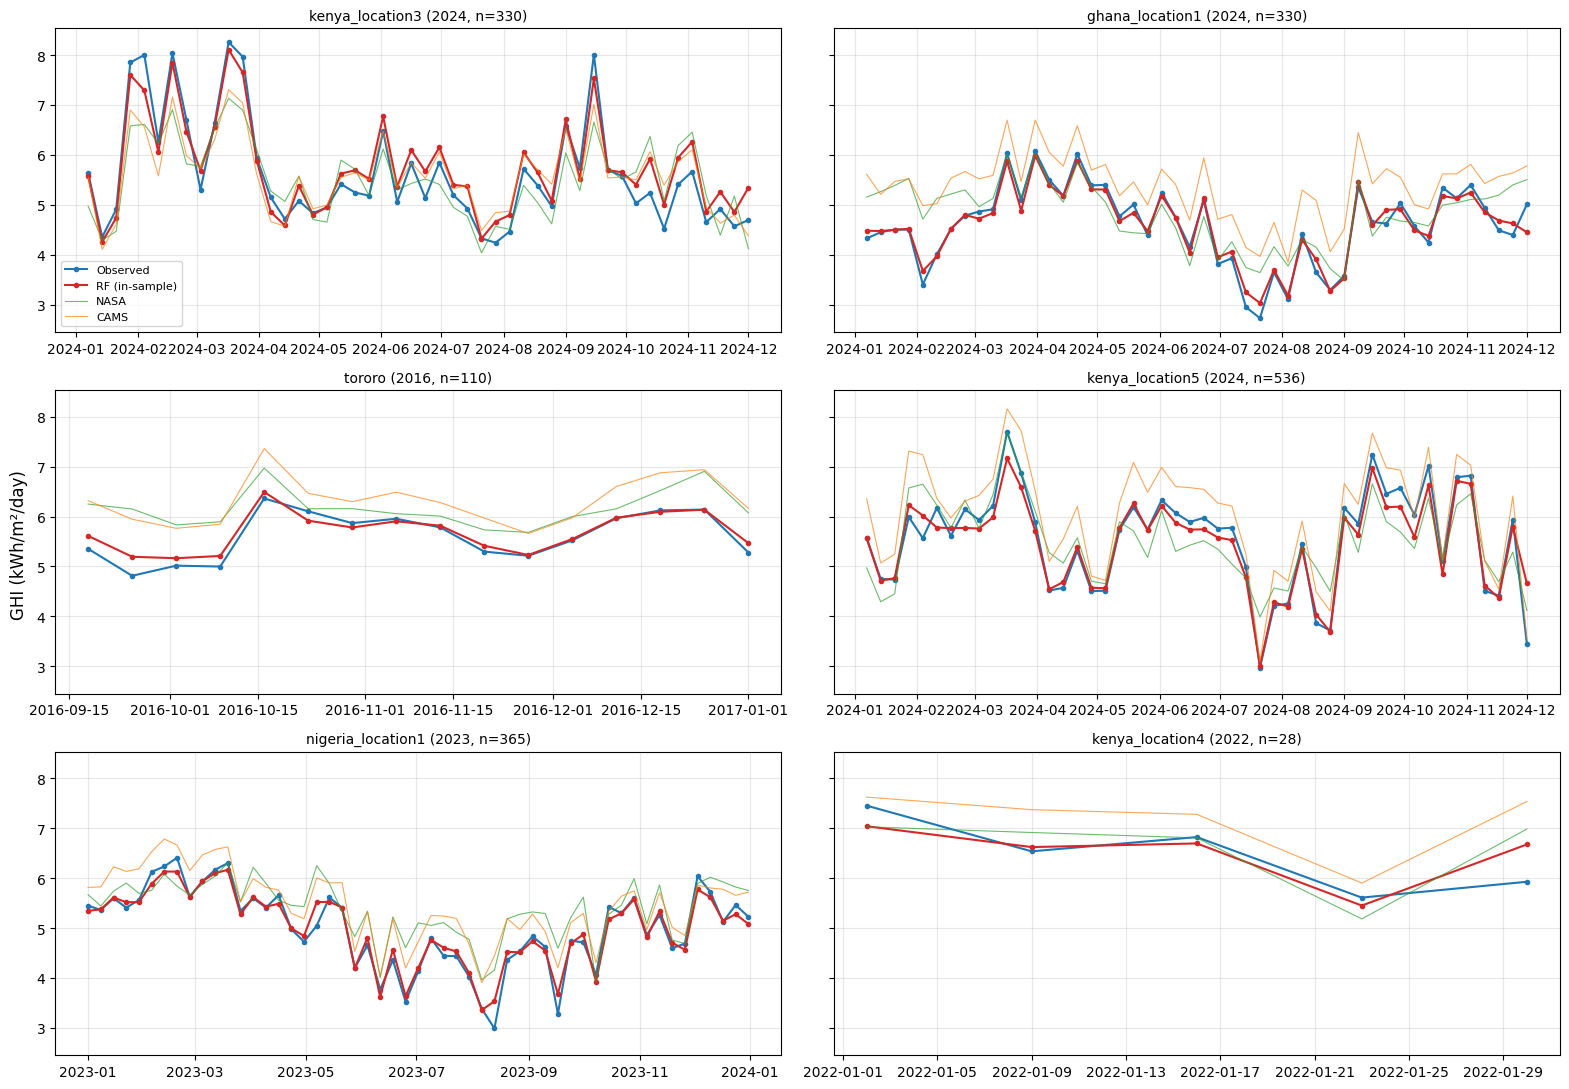

In [35]:
# Predict on every training row (in-sample). Useful for the
# "model isn't broken" sanity check; never the actual validation.
y_pred_train = pd.Series(
    bundle.regressor.predict(processed.X()), index=processed.df.index,
)
diag_df = processed.df.copy()
diag_df["y_pred"] = y_pred_train
diag_df["date"] = pd.to_datetime(diag_df["date"])

# Pick 6 stations with the most rows for the time-series grid.
plot_stations = (
    diag_df.groupby("location").size().sort_values(ascending=False).head(6).index.tolist()
)
print(f"Plotting yearly time series for: {plot_stations}")

fig, axes = plt.subplots(3, 2, figsize=(16, 11), sharey=True)
for ax, loc in zip(axes.flat, plot_stations):
    sub = diag_df[diag_df["location"] == loc].sort_values("date")
    # Restrict to the most recent year for readability.
    last_year = sub["date"].dt.year.max()
    sub = sub[sub["date"].dt.year == last_year]
    weekly = (
        sub.set_index("date")
        [[spec.target_column, "y_pred",
          "sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day"]]
        .resample("W").mean()
    )
    ax.plot(weekly.index, weekly[spec.target_column], "-o", ms=3, label="Observed", color="C0")
    ax.plot(weekly.index, weekly["y_pred"], "-o", ms=3, label="RF (in-sample)", color="C3")
    ax.plot(weekly.index, weekly["sat_ghi_nasa_kwh_m2_day"], "-", lw=0.8, label="NASA", color="C2", alpha=0.7)
    ax.plot(weekly.index, weekly["sat_ghi_cams_kwh_m2_day"], "-", lw=0.8, label="CAMS", color="C1", alpha=0.7)
    ax.set_title(f"{loc} ({last_year}, n={len(sub):,})", fontsize=10)
    ax.grid(alpha=0.3)
axes[0, 0].legend(fontsize=8, loc="lower left")
fig.supylabel("GHI (kWh/m²/day)")
fig.tight_layout()
plt.show()

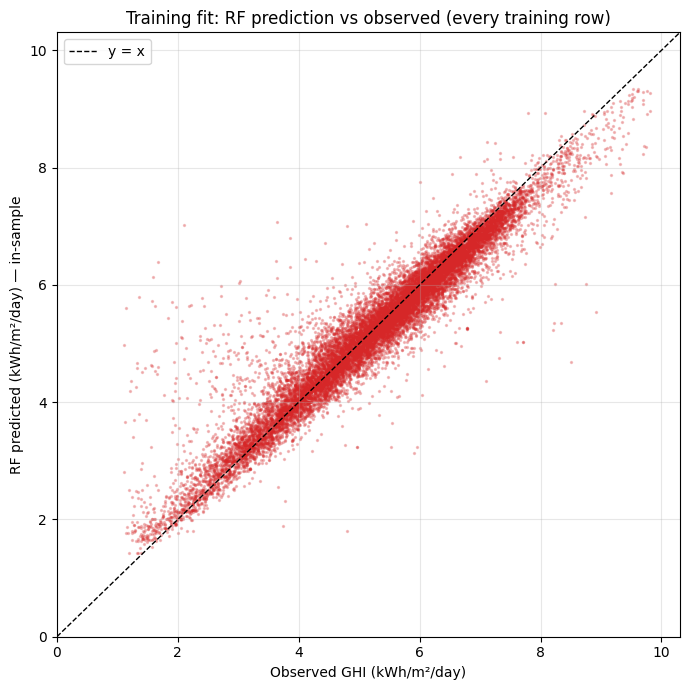

In-sample training fit:
  RMSE = 0.427
  MAE  = 0.271
  MBE  = -0.005


In [36]:
# Predicted-vs-observed scatter on all training rows. The RF should
# fit close to the diagonal in-sample; offsets here would mean the
# preprocessing or training pipeline is broken before we even get to
# generalisation.
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(diag_df[spec.target_column], diag_df["y_pred"],
           s=2, alpha=0.25, color="C3")
hi = max(diag_df[spec.target_column].max(), diag_df["y_pred"].max()) * 1.05
ax.plot([0, hi], [0, hi], "k--", lw=1, label="y = x")
ax.set_xlim(0, hi); ax.set_ylim(0, hi)
ax.set_xlabel("Observed GHI (kWh/m²/day)")
ax.set_ylabel("RF predicted (kWh/m²/day) — in-sample")
ax.set_title("Training fit: RF prediction vs observed (every training row)")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

err = diag_df["y_pred"] - diag_df[spec.target_column]
print(f"In-sample training fit:")
print(f"  RMSE = {np.sqrt((err**2).mean()):.3f}")
print(f"  MAE  = {np.abs(err).mean():.3f}")
print(f"  MBE  = {err.mean():.3f}")

## 6 — Validate against the Katongole 54-station network

The recomputation generates daily predictions for every Katongole
station for the validation year, aggregates monthly, and compares to the
2017–2022 climatology values. Stations whose `geohash5` overlaps a
training station's are flagged: the model has seen the satellite
features for those cells during training, even though the targets and
years differ — so its metrics there carry a small advantage. Both the
all-stations and overlap-removed metrics are reported.

In [37]:
katongole = pd.read_csv(KATONGOLE_CSV)
katongole["geohash5"] = [
    pygeohash.encode(lat, lon, precision=5)
    for lat, lon in zip(katongole["latitude"], katongole["longitude"])
]
training_geohashes = set(processed.df["geohash5"].unique())
katongole["seen_in_training_geohash5"] = katongole["geohash5"].isin(training_geohashes)
print(f"{len(katongole)} Katongole stations; "
      f"{int(katongole['seen_in_training_geohash5'].sum())} sit in a training-station geohash5 cell.")
katongole.head(3)

56 Katongole stations; 6 sit in a training-station geohash5 cell.


,location,latitude,longitude,altitude,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Av,geohash5,seen_in_training_geohash5
0,Ndejje ss,0.610600,32.47527,1223.0,2.6,3.0,4.1,4.8,5.2,5.5,5.6,5.1,4.0,3.6,2.9,2.4,4.1,s8p56,False
1,Entebbe WME,0.048611,32.47250,1149.0,4.6,4.3,4.6,4.3,4.1,3.7,4.0,4.0,4.0,4.3,4.1,4.1,4.2,s8p06,False
2,Wanyange GS,0.483497,33.24372,1346.0,4.7,4.9,5.1,4.8,4.5,4.2,4.0,4.4,4.5,4.6,4.6,4.5,4.6,s8pdu,False


In [39]:
# Build the inference frame for all 54 stations × the validation year.
#
# IMPORTANT: Katongole station coordinates do NOT sit exactly on the
# warehouse grid. Each Katongole station's geohash5 (~5 km cells) is
# typically *different* from the geohash5 of the nearest 0.5°-spaced
# warehouse grid point. An exact-geohash join would drop ~44 of 54
# stations. Instead, we map each station to the nearest warehouse cell
# that has 2024 data and pull satellite features from that cell.
#
# This mirrors what NASA POWER itself does at API request time: any
# query lat/lon resolves to the nearest 0.5° grid point. The model's
# AltitudeFeature still uses the station's exact (lat, lon) via pvlib,
# so altitude varies per-station even when stations share a warehouse
# satellite cell.
from susse.warehouse_ops.io.repositories import SatelliteRepository

VAL_START = date(VALIDATION_YEAR, 1, 1)
VAL_END = date(VALIDATION_YEAR, 12, 31)
sat_repo = SatelliteRepository(bq=bq, tables=tables)

# 1) Discover warehouse grid points that have full 2024 NASA + CAMS data.
warehouse_grid = bq.query(f'''
    SELECT geohash5,
           ANY_VALUE(latitude) AS wh_lat,
           ANY_VALUE(longitude) AS wh_lon,
           COUNT(DISTINCT date) AS n_days,
           COUNT(DISTINCT source) AS n_sources
    FROM `{tables.irradiance_daily}`
    WHERE date BETWEEN DATE("{VAL_START}") AND DATE("{VAL_END}")
      AND source IN ("NASA", "CAMS")
    GROUP BY geohash5
    HAVING n_days >= 300 AND n_sources = 2
''')
print(f"Warehouse-covered cells with full 2024 NASA+CAMS coverage: {len(warehouse_grid):,}")

# 2) For each Katongole station, find the nearest warehouse cell.
# Euclidean on (lat, lon) is fine over Uganda's ~6° span — < 0.05% bias
# at this scale; far cheaper than great-circle, and we only need the
# argmin which is invariant to monotonic distance transforms.
import numpy as np

wh_xy = warehouse_grid[["wh_lat", "wh_lon"]].to_numpy()
wh_gh = warehouse_grid["geohash5"].to_numpy()

def _nearest_warehouse_geohash(lat: float, lon: float) -> tuple[str, float, float, float]:
    d2 = (wh_xy[:, 0] - lat) ** 2 + (wh_xy[:, 1] - lon) ** 2
    j = int(np.argmin(d2))
    return wh_gh[j], float(wh_xy[j, 0]), float(wh_xy[j, 1]), float(np.sqrt(d2[j]))

mapping = pd.DataFrame([
    {
        "location": row.location,
        "lat": float(row.latitude),
        "lon": float(row.longitude),
        "warehouse_geohash5": (gh := _nearest_warehouse_geohash(row.latitude, row.longitude))[0],
        "warehouse_lat": gh[1],
        "warehouse_lon": gh[2],
        "snap_distance_deg": gh[3],
    }
    for row in katongole.itertuples(index=False)
])
print(f"Nearest-warehouse-cell mapping for {len(mapping)} Katongole stations:")
print(f"  median snap distance: {mapping['snap_distance_deg'].median():.3f}° "
      f"(~{111*mapping['snap_distance_deg'].median():.0f} km)")
print(f"  max snap distance:    {mapping['snap_distance_deg'].max():.3f}° "
      f"(~{111*mapping['snap_distance_deg'].max():.0f} km)")
unique_wh_gh = tuple(mapping["warehouse_geohash5"].unique())
print(f"  unique warehouse cells used: {len(unique_wh_gh)}")

/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Warehouse-covered cells with full 2024 NASA+CAMS coverage: 1,976
Nearest-warehouse-cell mapping for 56 Katongole stations:
  median snap distance: 0.041° (~5 km)
  max snap distance:    0.311° (~35 km)
  unique warehouse cells used: 49


In [40]:
# 3) Pull warehouse features for the union of mapped warehouse cells.
irr_wide = sat_repo.daily_irradiance_by_geohash(
    VAL_START, VAL_END,
    sources=("NASA", "CAMS"),
    geohash5s=unique_wh_gh,
)
nasa_aux = sat_repo.long_aux_pivoted(
    table_fqn=tables.nasa_daily_vars_long,
    column_prefix="nasa",
    start=VAL_START, end=VAL_END,
    variable_ids=NASA_AUX_VARIABLE_IDS,
    geohash5s=unique_wh_gh,
)
cams_aux = sat_repo.long_aux_pivoted(
    table_fqn=tables.cams_daily_vars_long,
    column_prefix="cams",
    start=VAL_START, end=VAL_END,
    variable_ids=CAMS_VARIABLE_IDS,
    geohash5s=unique_wh_gh,
)
print(f"Pulled: irradiance={len(irr_wide):,} | nasa_aux={len(nasa_aux):,} | cams_aux={len(cams_aux):,}")

# 4) Build per-(warehouse_geohash5, date) features.
geohash_features = (
    irr_wide
    .merge(nasa_aux, on=["date", "geohash5"], how="left")
    .merge(cams_aux, on=["date", "geohash5"], how="left")
    .rename(columns={"geohash5": "warehouse_geohash5"})
)

# 5) Cross-join each station to its mapped warehouse cell's features.
inference_df = mapping.merge(
    geohash_features, on="warehouse_geohash5", how="inner",
)
# Recompute the station's OWN geohash5 (used for lat/lon-derived
# features and for the geohash-overlap check vs training stations).
inference_df["geohash5"] = [
    pygeohash.encode(la, lo, precision=5)
    for la, lo in zip(inference_df["lat"], inference_df["lon"])
]
print(f"Total inference rows: {len(inference_df):,} "
      f"({inference_df['location'].nunique()} of {len(katongole)} stations × "
      f"{inference_df['date'].nunique()} dates)")

/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Pulled: irradiance=17,934 | nasa_aux=17,934 | cams_aux=17,934
Total inference rows: 20,496 (56 of 56 stations × 366 dates)


In [41]:
# Data sanity check — did we actually pull real 2024 NASA + CAMS data
# for the Katongole stations, or are key features missing / NaN?
print("=== Inference frame health (Katongole 2024) ===")
print(f"Date range:        {inference_df['date'].min()} .. {inference_df['date'].max()}")
print(f"Days per station:  {inference_df.groupby('location').size().describe()[['min', 'max', 'mean']].round(1).to_dict()}")
print(f"Unique geohashes:  {inference_df['geohash5'].nunique()}  (54 Katongole stations)")
print()

key_check_cols = [
    c for c in (
        "sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day",
        "nasa_clearness_index", "nasa_aod_550_adj", "nasa_cloud_amount",
        "cams_ghi_clear",
    )
    if c in inference_df.columns
]
print("Per-column NaN % + value range on the inference frame:")
diag = pd.DataFrame({
    "nan_%": (inference_df[key_check_cols].isna().mean() * 100).round(2),
    "min": inference_df[key_check_cols].min().round(3),
    "median": inference_df[key_check_cols].median().round(3),
    "max": inference_df[key_check_cols].max().round(3),
})
print(diag.to_string())
print()
# Cross-check: does the Katongole 2024 satellite GHI distribution
# overlap the training GHI distribution? If the medians look very
# different, we have a covariate-shift smoking gun.
print("Training vs Katongole-2024 satellite GHI distribution:")
for col in ("sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day"):
    if col in processed.df.columns and col in inference_df.columns:
        t_med = processed.df[col].median()
        v_med = inference_df[col].median()
        print(f"  {col:30s}  train median={t_med:.2f}  Katongole-2024 median={v_med:.2f}  Δ={v_med-t_med:+.2f}")

=== Inference frame health (Katongole 2024) ===
Date range:        2024-01-01 .. 2024-12-31
Days per station:  {'min': 366.0, 'max': 366.0, 'mean': 366.0}
Unique geohashes:  52  (54 Katongole stations)

Per-column NaN % + value range on the inference frame:
                         nan_%    min  median     max
sat_ghi_nasa_kwh_m2_day    0.0  1.550   5.280   8.000
sat_ghi_cams_kwh_m2_day    0.0  0.780   5.638   8.228
nasa_clearness_index       0.0  0.150   0.530   0.760
nasa_aod_550_adj           0.0  0.100   0.290   1.400
nasa_cloud_amount          0.0  1.040  76.530  99.880
cams_ghi_clear             0.0  5.537   7.151   8.230

Training vs Katongole-2024 satellite GHI distribution:
  sat_ghi_nasa_kwh_m2_day         train median=5.62  Katongole-2024 median=5.28  Δ=-0.34
  sat_ghi_cams_kwh_m2_day         train median=5.90  Katongole-2024 median=5.64  Δ=-0.26


In [42]:
# Apply the trained bundle's feature spec to the inference frame so
# columns line up with X_train, then predict.
from susse.training import load_bundle

# Reload from disk to mirror the portal's load path (proves the bundle
# is self-contained — we don't carry the in-memory regressor over).
restored = load_bundle(
    BUNDLE_DEST,
    providers={"altitude": PvlibElevationProvider()},
)

# Wrap in a TrainingDataset shell so Preprocessor.apply works. The
# manifest fields are not load-bearing for inference.
inference_dataset = TrainingDataset(
    df=inference_df.assign(y_ghi_kwh_m2_day=np.nan),
    manifest=manifest,  # reuse the training-side manifest as a stand-in
)
inference_spec = restored.feature_spec
# Inference frames don't have ground truth; disable the target-NaN drop
# policy so every row survives. Cleaners that reference the target are
# also skipped at the spec level — they're target-curation only.
inference_spec_for_predict = FeatureSpec(
    target_column=inference_spec.target_column,
    feature_columns=inference_spec.feature_columns,
    cleaners=(),  # no target-cleaning at inference time
    derived_features=inference_spec.derived_features,
    id_columns=inference_spec.id_columns,
    dropna_target=False,
    dropna_features=False,
)
inference_processed = Preprocessor(inference_spec_for_predict).apply(inference_dataset)

# Predict.
inference_predictions = restored.regressor.predict(inference_processed.X())
inference_processed.df["y_pred_kwh_m2_day"] = inference_predictions.values
print(f"Predictions: {len(inference_processed.df):,} daily values across {len(katongole)} stations")

Predictions: 20,496 daily values across 56 stations


In [43]:
# Aggregate daily predictions to monthly means per station.
monthly = (
    inference_processed.df
    .assign(month=lambda d: pd.to_datetime(d["date"]).dt.month)
    .groupby(["location", "month"])["y_pred_kwh_m2_day"]
    .mean()
    .reset_index()
    .rename(columns={"y_pred_kwh_m2_day": "monthly_pred"})
)

# Reshape Katongole CSV from wide (Jan..Dec) to long for the join.
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
katongole_long = katongole.melt(
    id_vars=["location", "latitude", "longitude", "altitude",
             "geohash5", "seen_in_training_geohash5"],
    value_vars=month_names,
    var_name="month_name", value_name="monthly_obs",
)
katongole_long["month"] = katongole_long["month_name"].apply(
    lambda m: month_names.index(m) + 1
)

# Join predictions to observations.
comparison = monthly.merge(
    katongole_long, on=["location", "month"], how="inner",
)
print(f"Comparison rows: {len(comparison)} ({comparison['location'].nunique()} stations × 12 months)")
comparison.head(5)

Comparison rows: 672 (56 stations × 12 months)


,location,month,monthly_pred,latitude,longitude,altitude,geohash5,seen_in_training_geohash5,month_name,monthly_obs
0,Aii-vu,1,5.343819,3.159782,31.01098,1092.0,s8w1c,False,Jan,3.4
1,Aii-vu,2,5.389593,3.159782,31.01098,1092.0,s8w1c,False,Feb,3.5
2,Aii-vu,3,6.053141,3.159782,31.01098,1092.0,s8w1c,False,Mar,3.4
3,Aii-vu,4,5.516520,3.159782,31.01098,1092.0,s8w1c,False,Apr,3.5
4,Aii-vu,5,5.630498,3.159782,31.01098,1092.0,s8w1c,False,May,3.3


In [44]:
# Add raw NASA + CAMS monthly predictions as baselines, mirroring
# paper Table IV's three-way comparison.
sat_monthly = (
    inference_processed.df.assign(month=lambda d: pd.to_datetime(d["date"]).dt.month)
    .groupby(["location", "month"])[["sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day"]]
    .mean()
    .reset_index()
)
comparison = comparison.merge(sat_monthly, on=["location", "month"], how="left")
comparison.head(5)

,location,month,monthly_pred,latitude,longitude,altitude,geohash5,seen_in_training_geohash5,month_name,monthly_obs,sat_ghi_nasa_kwh_m2_day,sat_ghi_cams_kwh_m2_day
0,Aii-vu,1,5.343819,3.159782,31.01098,1092.0,s8w1c,False,Jan,3.4,5.747419,5.971102
1,Aii-vu,2,5.389593,3.159782,31.01098,1092.0,s8w1c,False,Feb,3.5,5.491034,5.953680
2,Aii-vu,3,6.053141,3.159782,31.01098,1092.0,s8w1c,False,Mar,3.4,5.949677,6.877044
3,Aii-vu,4,5.516520,3.159782,31.01098,1092.0,s8w1c,False,Apr,3.5,5.561667,5.994743
4,Aii-vu,5,5.630498,3.159782,31.01098,1092.0,s8w1c,False,May,3.3,5.473871,6.110427


In [45]:
# Paper Table IV equivalent: cross-station mean of (RMSE, nRMSE, MAE,
# nMAE, MBE, R², IOA) for the RF model and each satellite baseline.
from susse.metrics import (
    index_of_agreement,
    mean_bias_error,
    normalised_mae,
    normalised_rmse,
)
from susse.training import score_predictions


def score_table(comp: pd.DataFrame, *, label: str) -> dict[str, float]:
    yt = comp["monthly_obs"]
    series = {
        "RF": comp["monthly_pred"],
        "NASA CERES": comp["sat_ghi_nasa_kwh_m2_day"],
        "CAMS": comp["sat_ghi_cams_kwh_m2_day"],
    }
    rows = []
    for src_label, yp in series.items():
        scores = score_predictions(yt, yp)
        rows.append({
            "split": label,
            "model": src_label,
            "n": scores.n_rows,
            "RMSE": round(scores.rmse, 3),
            "nRMSE_%": round(normalised_rmse(yt, yp), 2),
            "MAE": round(scores.mae, 3),
            "nMAE_%": round(normalised_mae(yt, yp), 2),
            "MBE": round(mean_bias_error(yt, yp), 3),
            "R²": round(scores.r2, 3),
            "IOA": round(index_of_agreement(yt, yp), 3),
        })
    return rows


score_rows = score_table(comparison, label="all 54 stations")
score_rows += score_table(
    comparison[~comparison["seen_in_training_geohash5"]],
    label="excluding training-geohash overlaps",
)
table_iv = pd.DataFrame(score_rows)
print("=== Paper Table IV equivalent ===")
print(table_iv.to_string(index=False))

=== Paper Table IV equivalent ===
                              split      model   n  RMSE  nRMSE_%   MAE  nMAE_%   MBE     R²   IOA
                    all 54 stations         RF 672 0.880    20.63 0.720   16.86 0.668 -1.160 0.555
                    all 54 stations NASA CERES 672 1.064    24.93 0.908   21.27 0.878 -2.154 0.500
                    all 54 stations       CAMS 672 1.282    30.03 1.131   26.49 1.116 -3.576 0.464
excluding training-geohash overlaps         RF 600 0.840    19.64 0.692   16.19 0.638 -1.466 0.529
excluding training-geohash overlaps NASA CERES 600 1.009    23.61 0.871   20.37 0.842 -2.562 0.486
excluding training-geohash overlaps       CAMS 600 1.236    28.91 1.098   25.69 1.083 -4.340 0.442


## 6.5 — Residual analysis on Katongole

If §6's metrics look bad relative to the paper, the three plots below
diagnose **why**:

* **Covariate-shift check** — KDE of selected features on the training
  frame vs the Katongole inference frame. If a feature distribution is
  noticeably different (e.g. altitude, AOD), the trained tree splits
  don't generalise — the model has been asked to extrapolate.
* **Monthly predicted-vs-observed scatter** — RF + NASA + CAMS, all 54
  stations × 12 months. Diagonal is perfect agreement. Look for:
  systematic offset bands (bias), heavy-tailed spread (variance), or
  visible cluster groups (per-region pathologies).
* **Per-station MBE bar chart** — which Katongole stations the RF
  systematically over- or under-predicts on. Outlier stations drive
  the headline error number; geohash-overlap stations are coloured
  separately.

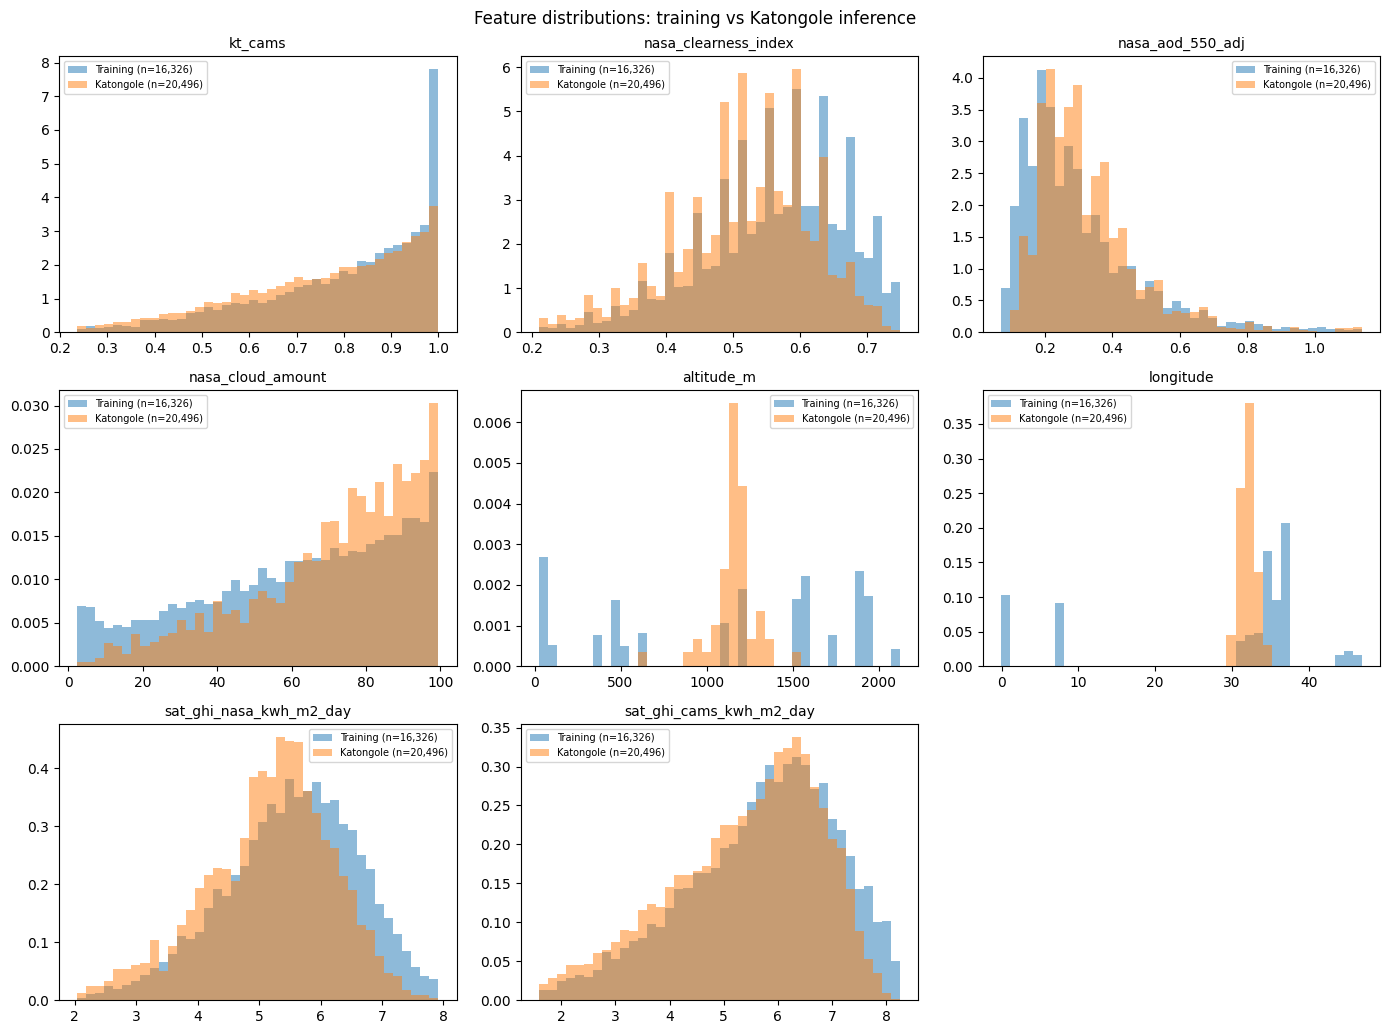

In [46]:
# Covariate shift: are Katongole features distributed like training
# features? KDE overlay for a curated set of "high-importance" inputs.
candidates = [
    "kt_cams", "nasa_clearness_index", "nasa_aod_550_adj",
    "nasa_cloud_amount", "altitude_m", "longitude",
    "sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day",
]
key_features = [
    f for f in candidates
    if f in processed.df.columns and f in inference_processed.df.columns
]
n = len(key_features)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows))
for ax, feat in zip(np.array(axes).flat, key_features):
    train_vals = processed.df[feat].dropna().to_numpy()
    val_vals = inference_processed.df[feat].dropna().to_numpy()
    bins = 40
    lo = float(np.nanquantile(np.r_[train_vals, val_vals], 0.005))
    hi = float(np.nanquantile(np.r_[train_vals, val_vals], 0.995))
    ax.hist(train_vals, bins=bins, range=(lo, hi),
            alpha=0.5, density=True, label=f"Training (n={len(train_vals):,})")
    ax.hist(val_vals, bins=bins, range=(lo, hi),
            alpha=0.5, density=True, label=f"Katongole (n={len(val_vals):,})")
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=7)
# Hide any unused subplots.
for ax in np.array(axes).flat[n:]:
    ax.axis("off")
fig.suptitle("Feature distributions: training vs Katongole inference")
fig.tight_layout()
plt.show()

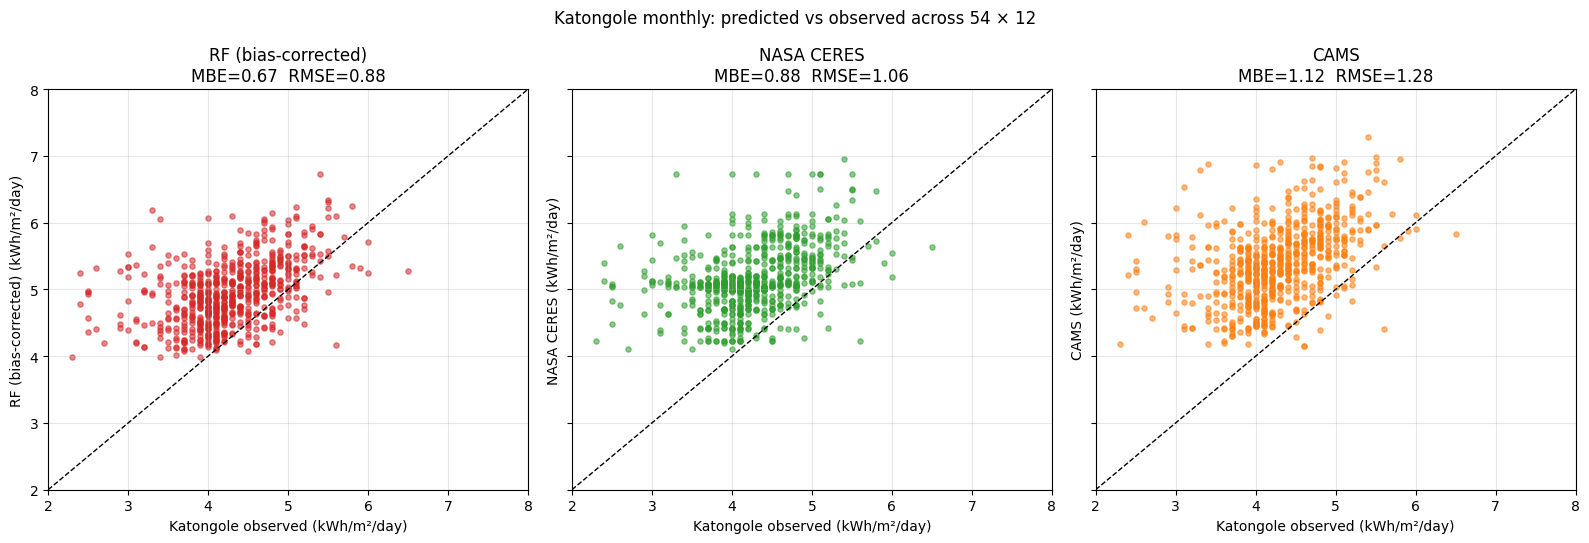

In [47]:
# Monthly predicted-vs-observed scatter for RF, NASA, CAMS.
# Diagonal = perfect agreement; horizontal-band offset = systematic
# bias. Run side-by-side to read the bias correction at a glance.
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharex=True, sharey=True)
series_cols = [
    ("monthly_pred",            "RF (bias-corrected)", "C3"),
    ("sat_ghi_nasa_kwh_m2_day", "NASA CERES",          "C2"),
    ("sat_ghi_cams_kwh_m2_day", "CAMS",                "C1"),
]
lim = (
    float(np.floor(comparison[["monthly_obs"] + [c for c, _, _ in series_cols]].min().min())),
    float(np.ceil(comparison[["monthly_obs"] + [c for c, _, _ in series_cols]].max().max())),
)
for ax, (col, label, color) in zip(axes, series_cols):
    ax.scatter(
        comparison["monthly_obs"], comparison[col],
        s=14, alpha=0.55, color=color,
    )
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Katongole observed (kWh/m²/day)")
    ax.set_ylabel(f"{label} (kWh/m²/day)")
    err = (comparison[col] - comparison["monthly_obs"]).dropna()
    ax.set_title(f"{label}\nMBE={err.mean():.2f}  RMSE={np.sqrt((err**2).mean()):.2f}")
    ax.grid(alpha=0.3)
fig.suptitle("Katongole monthly: predicted vs observed across 54 × 12")
fig.tight_layout()
plt.show()

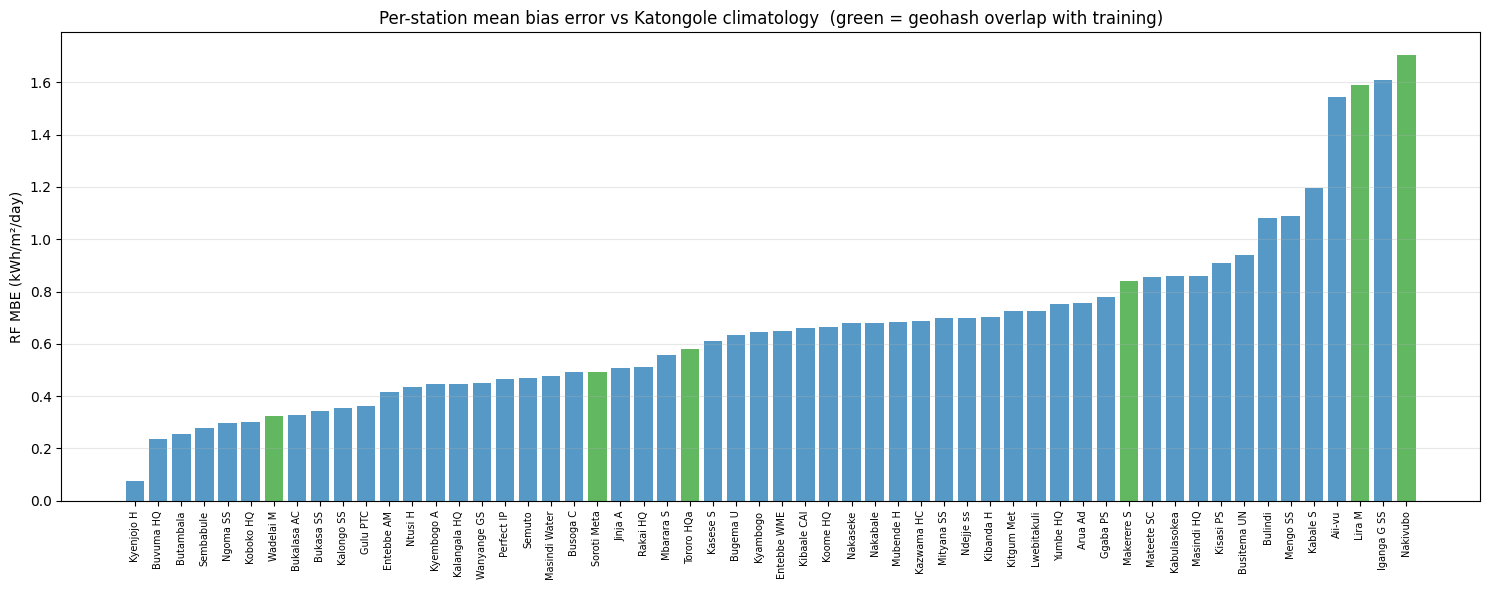

Worst over-prediction:
             rf_mbe  rf_rmse  seen_in_training
location                                      
Kabale S      1.196    1.282             False
Aii-vu        1.544    1.706             False
Lira M        1.590    1.692              True
Iganga G SS   1.608    1.740             False
Nakivubo      1.706    1.788              True

Worst under-prediction:
            rf_mbe  rf_rmse  seen_in_training
location                                     
Kyenjojo H   0.075    0.370             False
Buvuma HQ    0.237    0.403             False
Butambala    0.255    0.512             False
Sembabule    0.278    0.507             False
Ngoma SS     0.298    0.491             False


In [48]:
# Per-station MBE on Katongole. Stations sorted by MBE so over-
# and under-prediction tails are visible. Stations whose geohash5
# overlaps a training station get a different colour — they should
# look better (familiar feature distributions) than the rest.
per_station = (
    comparison.assign(rf_residual=lambda d: d["monthly_pred"] - d["monthly_obs"])
    .groupby("location")
    .agg(
        rf_mbe=("rf_residual", "mean"),
        rf_rmse=("rf_residual",
                 lambda r: float(np.sqrt(((r ** 2).mean())))),
        seen_in_training=("seen_in_training_geohash5", "first"),
    )
    .sort_values("rf_mbe")
)

fig, ax = plt.subplots(figsize=(15, 6))
colors = ["C2" if seen else "C0" for seen in per_station["seen_in_training"]]
ax.bar(range(len(per_station)), per_station["rf_mbe"], color=colors, alpha=0.75)
ax.axhline(0, color="k", lw=0.7)
ax.set_xticks(range(len(per_station)))
ax.set_xticklabels(per_station.index, rotation=90, fontsize=7)
ax.set_ylabel("RF MBE (kWh/m²/day)")
ax.set_title(
    "Per-station mean bias error vs Katongole climatology  "
    "(green = geohash overlap with training)"
)
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

print("Worst over-prediction:")
print(per_station.tail(5).round(3).to_string())
print("\nWorst under-prediction:")
print(per_station.head(5).round(3).to_string())

## 7 — Figures

* **Figure 2 equivalent** — monthly comparison plots for 16 representative
  Ugandan stations (4 regions × 4 stations). Selection is configurable;
  default picks the first four stations sorted alphabetically per region
  if region tags are absent.
* **Figure 3 equivalent** — top feature importances from the trained RF.

/tmp/ipykernel_1665673/3188978942.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: float(np.sqrt(((g["monthly_pred"] - g["monthly_obs"]) ** 2).mean())))


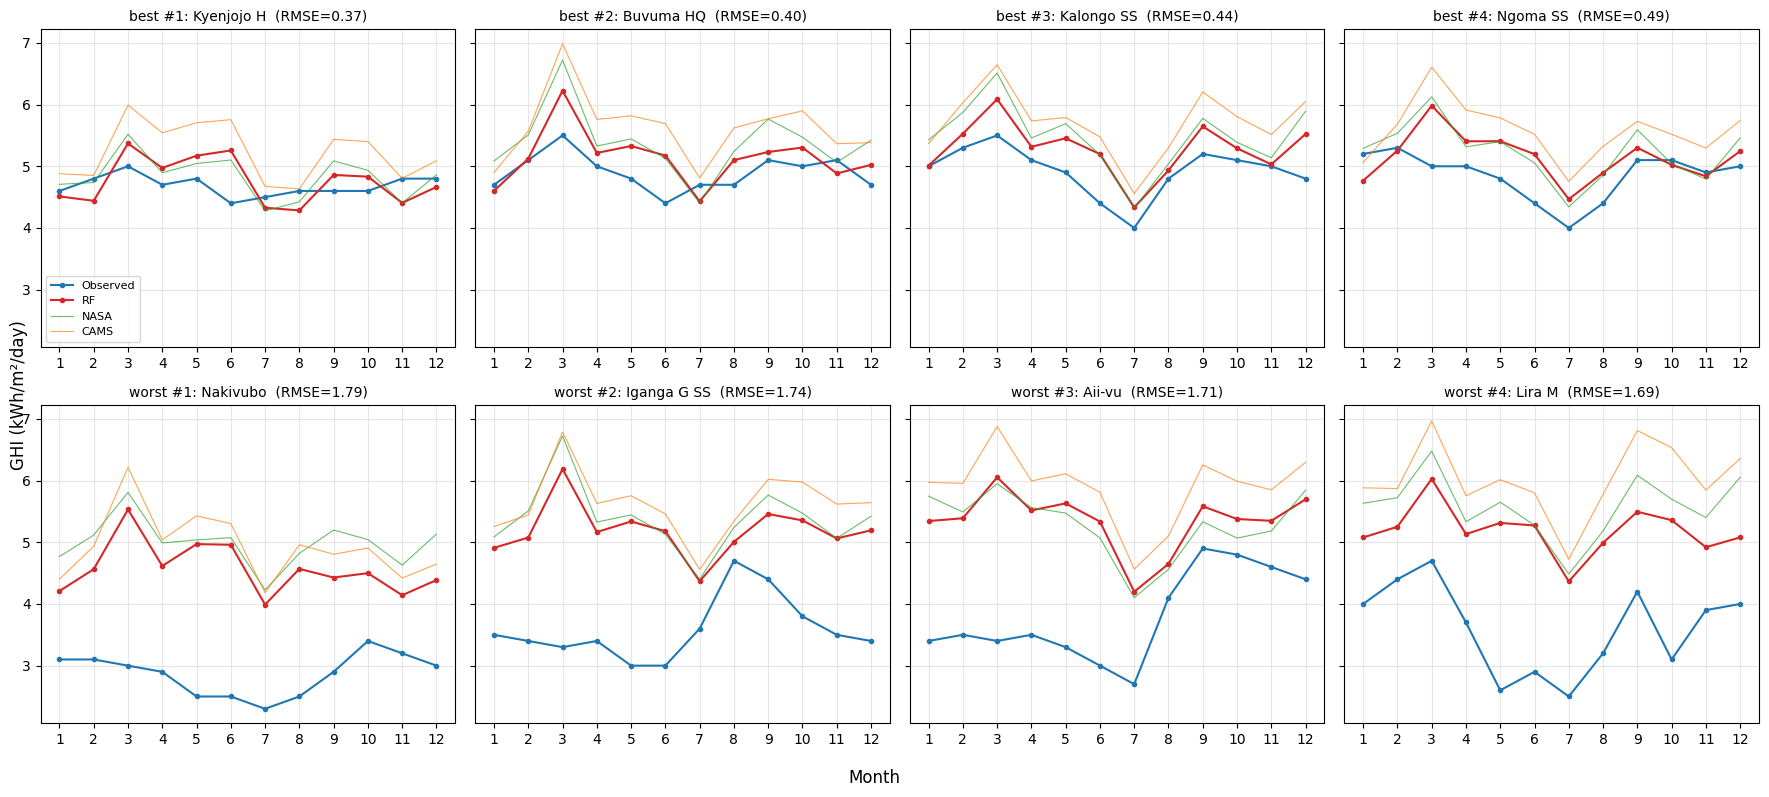

Best 4 (lowest monthly RMSE):
location
Kyenjojo H    0.370
Buvuma HQ     0.403
Kalongo SS    0.435
Ngoma SS      0.491

Worst 4 (highest monthly RMSE):
location
Lira M         1.692
Aii-vu         1.706
Iganga G SS    1.740
Nakivubo       1.788


In [49]:
# Figure 2 — pick the 4 best- and 4 worst-fitting Katongole stations
# by monthly RMSE. The grid surfaces both extremes of the generalisation
# curve at once: where the model works (top row) and where it fails
# (bottom row). Style matches the §5.5 training plots — `-o ms=3`
# markers for Observed and RF, plain thin lines for NASA / CAMS.
per_station_rmse = (
    comparison.groupby("location")
    .apply(lambda g: float(np.sqrt(((g["monthly_pred"] - g["monthly_obs"]) ** 2).mean())))
    .sort_values()
)
best_4 = per_station_rmse.head(4).index.tolist()
worst_4 = per_station_rmse.tail(4).index.tolist()[::-1]  # worst first within the row
plot_stations = best_4 + worst_4
plot_labels = (
    [f"best #{i+1}" for i in range(4)]
    + [f"worst #{i+1}" for i in range(4)]
)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
flat_axes = list(axes.flat)
for ax, loc, label in zip(flat_axes, plot_stations, plot_labels):
    sub = comparison[comparison["location"] == loc].sort_values("month")
    rmse = per_station_rmse[loc]
    ax.plot(sub["month"], sub["monthly_obs"], "-o", ms=3,
            label="Observed", color="C0")
    ax.plot(sub["month"], sub["monthly_pred"], "-o", ms=3,
            label="RF", color="C3")
    ax.plot(sub["month"], sub["sat_ghi_nasa_kwh_m2_day"], "-", lw=0.8,
            label="NASA", color="C2", alpha=0.7)
    ax.plot(sub["month"], sub["sat_ghi_cams_kwh_m2_day"], "-", lw=0.8,
            label="CAMS", color="C1", alpha=0.7)
    ax.set_title(f"{label}: {loc}  (RMSE={rmse:.2f})", fontsize=10)
    ax.set_xticks(range(1, 13))
    ax.grid(alpha=0.3)
flat_axes[0].legend(loc="lower left", fontsize=8)
fig.supxlabel("Month")
fig.supylabel("GHI (kWh/m²/day)")
fig.tight_layout()
plt.show()

print("Best 4 (lowest monthly RMSE):")
print(per_station_rmse.head(4).round(3).to_string())
print("\nWorst 4 (highest monthly RMSE):")
print(per_station_rmse.tail(4).round(3).to_string())

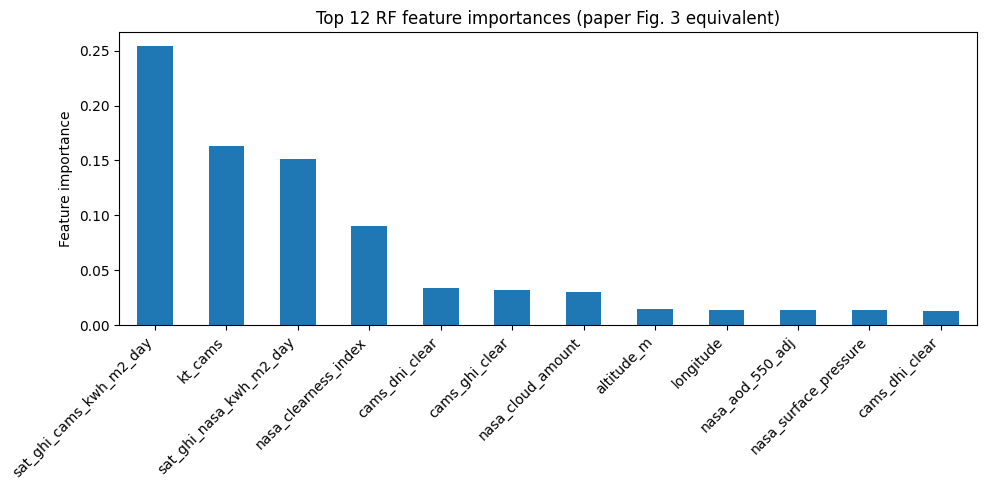

sat_ghi_cams_kwh_m2_day    0.253900
kt_cams                    0.163081
sat_ghi_nasa_kwh_m2_day    0.151594
nasa_clearness_index       0.090173
cams_dni_clear             0.033691
cams_ghi_clear             0.032215
nasa_cloud_amount          0.030700
altitude_m                 0.014685
longitude                  0.013842
nasa_aod_550_adj           0.013792
nasa_surface_pressure      0.013696
cams_dhi_clear             0.013004
dtype: float64

In [50]:
# Figure 3 — top-N feature importances from the fitted RF.
# The wrapper exposes a `.feature_importances(feature_names)` accessor
# that returns a pandas Series indexed by column name — no need to
# reach into the underlying sklearn estimator.
importances = (
    bundle.regressor
    .feature_importances(processed.feature_columns)
    .sort_values(ascending=False)
)

top_n = 12
fig, ax = plt.subplots(figsize=(10, 5))
importances.head(top_n).plot.bar(ax=ax)
ax.set_ylabel("Feature importance")
ax.set_title(f"Top {top_n} RF feature importances (paper Fig. 3 equivalent)")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
plt.show()
importances.head(top_n)

## 8 — Bundle deliverable for Irradiation_Portal

The portal loads a `TrainedBundle` from a fixed directory. After this
notebook runs cleanly the directory at `BUNDLE_DEST` contains:

```
mukiibi_mikelson_2026/
├── model/
│   ├── model_kind.txt       # → "random_forest"
│   ├── params.json          # → {n_estimators: 200, min_samples_leaf: 5, …}
│   └── state.joblib         # the fitted sklearn estimator
├── feature_spec.json        # cleaners + derived features + pass-through cols
├── metadata.json            # train + val + baseline ScoreSet, splitter name, etc.
└── source_manifest.json     # the warehouse-state snapshot used to build the dataset
```

Point the portal's bundle path at this directory. Provider injection at
load time is one line: `load_bundle(dir,
providers={"altitude": PvlibElevationProvider()})` — the rest is
self-describing inside the bundle.

In [51]:
# Final sanity check: re-load and re-predict to verify the on-disk
# bundle is portable. This is the same call shape the portal will use.
restored = load_bundle(
    BUNDLE_DEST,
    providers={"altitude": PvlibElevationProvider()},
)
print(f"Reloaded: {type(restored.regressor).__name__}")
print(f"Feature spec hash matches: "
      f"{restored.feature_spec.to_json() == bundle.feature_spec.to_json()}")
print(f"Bundle is at: {BUNDLE_DEST}")
print()
print("Next step: hand this directory path to Irradiation_Portal.")

Reloaded: RandomForestRegressor
Feature spec hash matches: True
Bundle is at: /home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/data/bundles/mukiibi_mikelson_2026

Next step: hand this directory path to Irradiation_Portal.


## 9 — Deviations from the paper (documented)

| | Paper | This recomputation | Why |
|---|---|---|---|
| Validation year | 2021 | 2024 | Our Uganda grid covers 2024 only; both years sit inside the Katongole 7-year window. |
| Outlier curation | inline (text §II.A) | `cleaners` chain in `FeatureSpec` | Architectural — the paper's rules now compose like any other cleaner. |
| Held-out stations | 2 of 24 stations spatially held out for Table III | All 28 stations train; only the Katongole network validates | Deployment bundle; 7% data sacrifice not justified for paper-internal Table III metric. Lose: daily-scale held-out RMSE. Keep: stronger model. |
| `day_of_year` integer | included alongside sin/cos | sin/cos only via `CyclicalDayOfYearFeature` | Cyclical encoding is information-equivalent; raw doy adds collinearity. |
| MERRA-2 OPeNDAP AOD | not used | not used | Paper uses NASA POWER's `AOD_55_ADJ` only. The standalone `MerraRegionJob` ingest is for the next-iteration model. |
| NASA DHI/DNI, CAMS DHI/DNI | included (4 of 39 predictors) | dropped | Infrastructure gap: these live only in `irradiance_daily`, not in the long aux tables FeatureService pivots from. Per paper Fig. 3 they sit below the top-9 features (top is `ghi_cams` >50%), so the impact on RMSE should be small. Filed as a follow-up to extend FeatureService. |

## What's next

* If `nRMSE_%` and `IOA` differ materially from the paper, inspect the
  cleaner output — the per-station/year missing-data threshold and the
  IQR fence are the two most sensitive levers.
* Once the numbers are within striking distance, set `LOG_TO_WANDB=True`
  and re-run; share the run URL with the co-author via the W&B team
  workspace.
* Future iteration: when the wider MERRA-2 AOD decomposition is in the
  warehouse (post-`b9`), add those columns to the `FeatureSelection` and
  see whether the model improves over this paper-faithful baseline.